# HCNN for Fully Observable Chaotic Systems

This notebook demonstrates the use of Historical Consistent Neural Networks (HCNNs) for modeling and forecasting fully observable chaotic systems. We will work with well-known chaotic systems such as the Lorenz system, Rabinovich-Fabrikant system, and Rossler system. The workflow includes data simulation, preprocessing, model training, and evaluation."

## 1. Import Libraries

We begin by importing the necessary libraries for data manipulation, visualization, and model development. "The `chaotic_data` module contains solvers for generating data from chaotic systems, and utility functions for preprocessing."

In [18]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chaotic_data import systems # more details about this can be found in a separate folder at the root of the repo

In [19]:
from utils import preprocess , plottings 

## 2. Load the Lorenz System

We'll simulate the Lorenz system, a classic chaotic system, over a time span of 20 seconds with a time step of 0.01. The Lorenz system is a classic example of a chaotic system. Here, we simulate its behavior over a time span of 20 seconds with a time step of 0.01. The initial conditions are set to `(1.0, 0.0, 1.25)`. The resulting data will have three dimensions corresponding to the system's state variables."
            

In [20]:
lorenz_data, _ = systems.LorenzSolver(start=0.0, stop=20.0, ics=(1.0, 0.0, 1.25), time_grid=0.01)
lorenz_data.shape  # Expected shape: (2000, 3)

torch.Size([2000, 3])

We plot the first state variable of the Lorenz system to observe its chaotic behavior over time."


In [21]:
plotter_lorenz  =plottings.ChaoticSystemPlotter(data=lorenz_data, system_name='Lorenz')

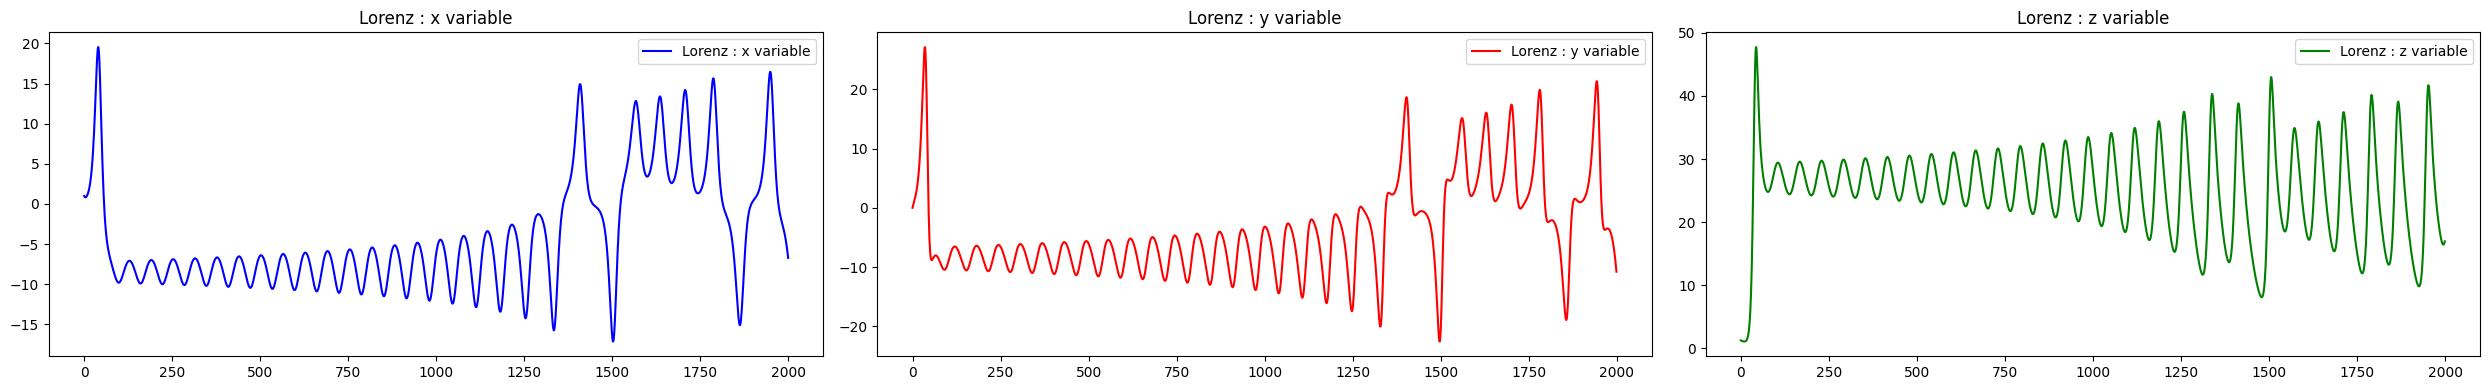

In [22]:
plotter_lorenz.plot_all_trajectories(render='horizontal')

The same approach can be applied to simulate and visualize other chaotic systems, such as the Rabinovich-Fabrikant and Rossler systems.


In [23]:
rabi_data, _= systems.RabinovichFabrikantSolver(start=0.0, stop=200.0, ics=(0.1 , 0.1 ,0.1), time_grid=0.1)
rabi_data.shape

torch.Size([2000, 3])

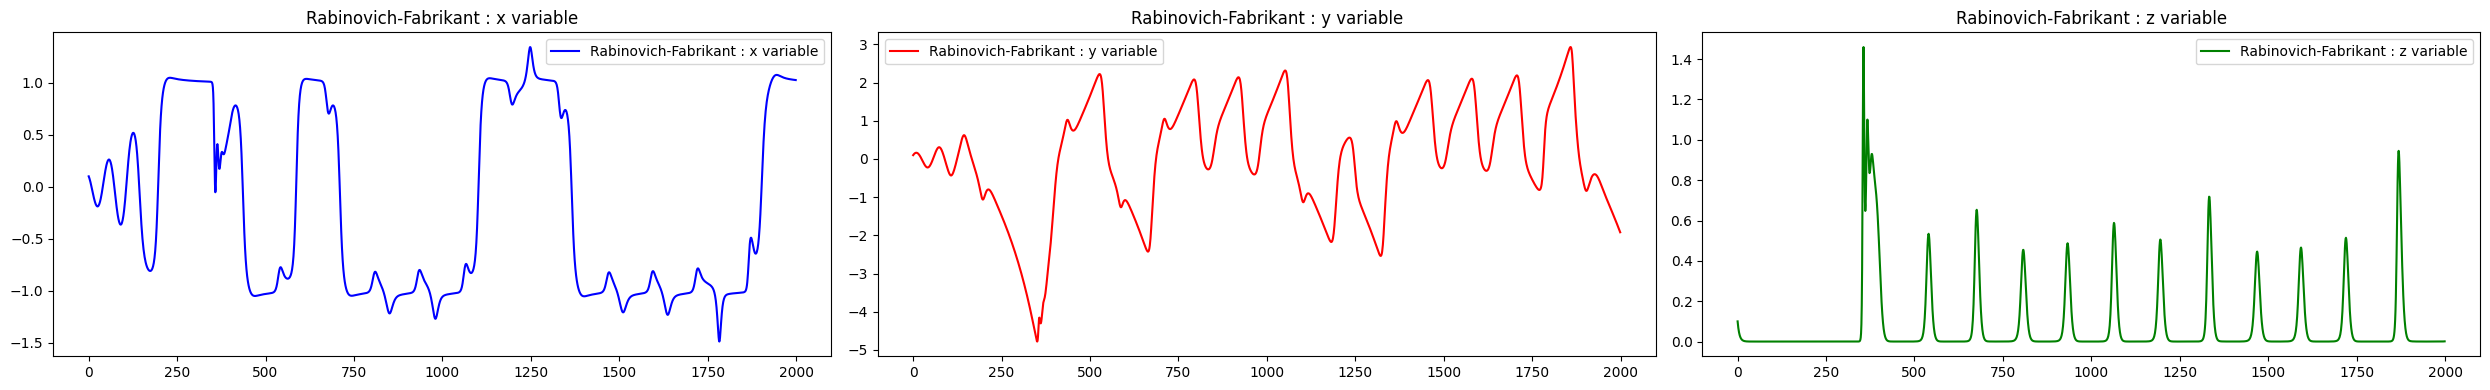

In [24]:
plotter_rabi = plottings.ChaoticSystemPlotter(data=rabi_data, system_name='Rabinovich-Fabrikant')
plotter_rabi.plot_all_trajectories(render='horizontal')

## 3. Normalize the Data

 stabilize the learning process, we normalize the data to a manageable range. Here, we use a scaling factor of 0.02 to scale the Lorenz system data.

In [25]:
norma = preprocess.Normalization_Strategy()   
scaled_lorenz, avg_lorenz = norma.Scale_ToNormalize(data=lorenz_data, scaling_factor=0.02)
print(scaled_lorenz.shape , avg_lorenz.shape)  # 

torch.Size([2000, 3]) torch.Size([3])


If needed, we can recover the original values using:                 "If needed, we can recover the original values from the normalized data using the `ScaleBackTo_originals` method."


In [26]:
original_lorenz = norma.ScaleBackTo_originals(
    scaled_tens_data=scaled_lorenz,
    scaling_factor=0.02,
    tens_avgs=avg_lorenz
)

original_lorenz.shape

(2000, 3)

## 4. Train-Test Split

Let's divide the time series into training and testing windows. We divide the normalized Lorenz data into training and testing sets. The first 1500 time steps are used for training, and the remaining 500 time steps are reserved for testing.
           

In [27]:
train_size = 1500
train_lorenz = scaled_lorenz[:train_size]
test_lorenz = scaled_lorenz[train_size:]
print(train_lorenz.shape, test_lorenz.shape)

torch.Size([1500, 3]) torch.Size([500, 3])


## 5. Prepare Batched Input Data

To train the HCNN models, we segment the time series into overlapping sequences using a sliding window approach. Here, we set the window size to 200 time steps."

In [28]:
data_sliding = preprocess.SlidingWindowDataset(data=train_lorenz, window_size=200)
sliced_data = data_sliding.sliding_windows_shift_to(train_lorenz, 200)

print(sliced_data.shape)   

torch.Size([1301, 200, 3])


You can also extract a long context window and its associated future observations. 

The context window can be located randomly within the train set (`random` in the image below)
or chosen to be carefully at the  end of the train set for forecast purpose (`last`).


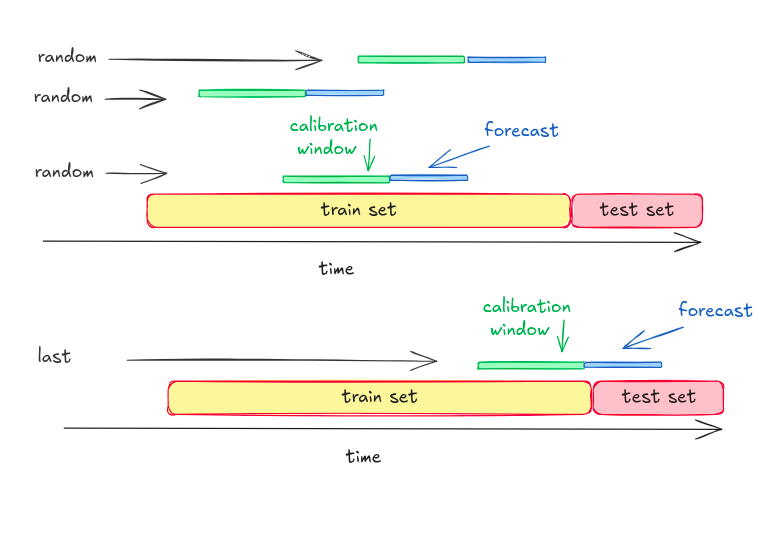

In [29]:
from IPython.display import Image


Image(filename='img_usage/sliding_windows_usage.png')

For a randomly selected context window of length 200, this method generates the subsequent 500 time steps. This approach can be utilized during inference to evaluate the model's ability to leverage a calibration window for forecasting. For instance, it is useful to test the model accuracy to predict the subsequent time steps. given the initial conditions.The sliding window approach allows us to extract context windows and their associated future observations. This is particularly useful for forecasting tasks.

In [30]:
calibration_window_length =200
forecast_window_length = 500

context_data_r, toforecast_data_r = data_sliding.contextwindow_testdata_generator(
    context_size=calibration_window_length, fcast_size=forecast_window_length, location='random_'
)

The same logic applies when the location is `last`.                 "The same logic applies when the context window is located at the end of the training set for forecasting purposes."


In [31]:
context_data_l, toforecast_data_l = data_sliding.contextwindow_testdata_generator(
    context_size=1, fcast_size=1499, location='last_'
)

## 6. DataLoader for Training

We wrap our training windows in a DataLoader to enable batch processing.

In [32]:
batch_size = 20
my_data_loader = preprocess.SlidingWindowDataLoader(dataset=sliced_data, batch_size=batch_size, shuffle=False)



## 7. Load HCNN Models

We'll now bring in the HCNN model architectures.

In [33]:
from HCNN.models import Vanilla_Model, PTF_Model, LForm_Model, LSpa_Model
from torch import nn

## 9. Train a Vanilla HCNN Model

We initialize a Vanilla HCNN model with the following configuration:

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `batch_size=data_window.size(0)`: Matches the batch size to the training data's batch size for efficient parallel processing.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.


In [35]:
vanilla_model = Vanilla_Model(
    n_obs_vars=3, n_hid_vars=5, 
    s0_nature='random_', train_s0=True, init_range=(-0.5, 0.5)
)


In [36]:
vanilla_model.name

'VanillaModel_obs3_hid5_randInit-0.5to0.5_trainableS0'

Lets check the vanilla model trainable parameters and their respective size.

In [37]:
vanilla_model.state_dict()  

OrderedDict([('s0',
              tensor([[ 0.4522,  0.3755, -0.2017,  0.3706, -0.2751,  0.0031, -0.3036,  0.1771]])),
             ('cell.A.weight',
              tensor([[ 0.0397,  0.2970, -0.0416,  0.1423, -0.0195, -0.3903,  0.2418, -0.4402],
                      [ 0.1489, -0.4884, -0.4279, -0.4944,  0.3865, -0.1669, -0.2714,  0.4802],
                      [ 0.3846,  0.3164,  0.0408, -0.4225, -0.1880,  0.0257,  0.0823,  0.2933],
                      [-0.0021,  0.3633, -0.4970, -0.4533,  0.3773, -0.2475,  0.0517, -0.1628],
                      [-0.1921,  0.0899, -0.0627,  0.2438,  0.3832, -0.4083, -0.1893, -0.3207],
                      [-0.3149, -0.3498,  0.3940,  0.3629, -0.0137,  0.3513, -0.3036, -0.2546],
                      [ 0.1824, -0.1689, -0.3977, -0.1290,  0.4894, -0.2884,  0.1199,  0.4809],
                      [-0.2535, -0.4665, -0.3391, -0.1702, -0.4674,  0.1038, -0.0737,  0.1636]]))])

In [38]:
for param in vanilla_model.parameters():
    print(param.shape)  

torch.Size([1, 8])
torch.Size([8, 8])


###  Training Loop

We iterate over batches from the DataLoader, updating the model at each step.
 We also perform forecasting after each training update, using the  random calibration window instantiated earlier on.

In [39]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=1e-4)

In [40]:
context_data_r.shape , toforecast_data_r.shape

(torch.Size([200, 3]), torch.Size([500, 3]))

In [ ]:
for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = vanilla_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {vanilla_model.s0.grad}")
        print(f"Gradient (A weights): {vanilla_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = vanilla_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

In [48]:
results_forecast.forecasts.shape

torch.Size([1, 500, 3])

In [ ]:
plotter_lorenz.plot_true_and_pred(true=toforecast_data_r, pred=results_forecast.forecasts[0, :, :], render='horizontal')

##  Partial Teacher Forcing Model


We initialize a Vanilla HCNN model with the following configuration:

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `batch_size=data_window.size(0)`: Matches the batch size to the training data's batch size for efficient parallel processing.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.

* `target_prob = 0.35`: specifies the target probability for the partial teacher forcing mechanism.

* `drop_output =False`: whether to drop the output after the partial teacher forcing is applied( when `False`, the dropout elements are included as part of the loss calculation.)


In [42]:

ptf_model =  PTF_Model(n_obs_vars=3, n_hid_vars=5, s0_nature='random_', train_s0=True, 
                       target_prob=0.35, drop_output=False)

In [43]:
ptf_model.name

'PTFModel_obs3_hid5_randInit-0.75to0.75_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(ptf_model.parameters(), lr=1e-4)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = ptf_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {ptf_model.s0.grad}")
        print(f"Gradient (A weights): {ptf_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = ptf_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

## LForm model

In [44]:
lform_model =  LForm_Model(n_obs_vars=3, n_hid_vars=5,
                                s0_nature='random_', train_s0=False, 
                               init_range=(-.25, .25), init_diag=1.0,)

In [45]:
lform_model.name

'LFormModel_obs3_hid5_randInit-0.25to0.25'

In [46]:
lform_model.state_dict()

OrderedDict([('s0',
              tensor([[ 0.1351,  0.2070,  0.1954, -0.1452, -0.2118, -0.2419,  0.1233,  0.0666]])),
             ('cell.A.weight',
              tensor([[-0.0856,  0.1525, -0.1303,  0.0056,  0.0214, -0.0713,  0.2162,  0.0267],
                      [-0.1220, -0.0495, -0.0011, -0.0902, -0.2053,  0.1326, -0.2169, -0.2064],
                      [ 0.0590, -0.0620, -0.0269, -0.2203, -0.1133, -0.2476, -0.2048,  0.0992],
                      [ 0.0617, -0.0385, -0.2398,  0.1671,  0.1327,  0.1937, -0.2180,  0.1126],
                      [-0.2364,  0.2435, -0.0400, -0.1798,  0.2423,  0.1511, -0.2040,  0.1163],
                      [-0.0153, -0.1049,  0.1145, -0.0568,  0.0428,  0.1924, -0.1034,  0.0175],
                      [-0.1199, -0.0850,  0.1664,  0.2108, -0.2234, -0.2406, -0.1015, -0.0074],
                      [-0.2143,  0.0813,  0.0170,  0.1255,  0.1587, -0.1300, -0.0995,  0.1242]])),
             ('cell.D.weight',
              tensor([[1., 0., 0., 0., 0., 0., 0

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lform_model.parameters(), lr=1e-2)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lform_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lform_model.s0.grad}")
        print(f"Gradient (A weights): {lform_model.cell.A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lform_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

## LSpa Model

### Random Block Sparsity

In [50]:
lspa_model  = LSpa_Model(n_obs_vars=3, n_hid_vars=10,
                                s0_nature='random_', train_s0=True, 
                                sparsity_ratio=0.25,  init_range=(-.25, .25), mask_type='random_block')

In [51]:
lspa_model.name

'LSpaModel_obs3_hid10_randInit-0.25to0.25_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lspa_model.parameters(), lr=1e-3)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lspa_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lspa_model.s0.grad}")
        print(f"Gradient (A weights): {lspa_model.cell.Sparse_A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lspa_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )

### Observable-linked Sparsity

In [52]:
lspa_model  = LSpa_Model(n_obs_vars=3, n_hid_vars=10,
                                s0_nature='random_', train_s0=True, 
                                sparsity_ratio=0.25,  init_range=(-.25, .25), mask_type='non_obs_block')

In [53]:
lspa_model.name

'LSpaModel_obs3_hid10_randInit-0.25to0.25_trainableS0'

In [ ]:
loss_fct = nn.MSELoss()
optimizer = torch.optim.Adam(lspa_model.parameters(), lr=1e-3)

for epoch in range(2):
    for batch_of_data in my_data_loader:

        optimizer.zero_grad()
        results_training = lspa_model.forward(data_window=batch_of_data)

        loss = loss_fct(results_training.expectations, batch_of_data)
        loss.backward()
        optimizer.step()

        print(f"Gradient (init state): {lspa_model.s0.grad}")
        print(f"Gradient (A weights): {lspa_model.cell.Sparse_A.weight.grad}")
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

        with torch.no_grad():
            results_forecast = lspa_model.forward(
                data_window=context_data_r.unsqueeze(0),
                forecast_horizon=forecast_window_length
            )